# Напишите заголовок проекта здесь

- Автор: Стогниева Дарья Александровна
- Дата: 28.01.2026

### Цели и задачи проекта

**Цель проекта:** провести исследовательский анализ рынка общественного питания в Москве и определить какое место будет выгоднее открыть инвесторам.

**Задачи проекта:**

1. Загрузить и ознакомиться с данными проекта;
2. Предобработать данные: преобразовать типы данных, обработать пропущенные значения, избавиться от явных и неявных дубликатов;
3. Изучить категории заведений, административные районы, сетевые и несетевые заведения, посадочные места, рейтинги, корреляции рейтинга, топ-15 сетей и средние чеки заведений.
4. Для каждого пункта оформить понятную визуализацию.
5. Оформить выводы и рекомендации.

### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
* `name` — название заведения;
* `address` — адрес заведения;
* `district` — административный район, в котором находится заведение, например Центральный административный округ;
* `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
* `hours` — информация о днях и часах работы;
* `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
* `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
            0 — заведение не является сетевым;
            1 — заведение является сетевым.
* `seats` — количество посадочных мест.



Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
* `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
* `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например:
        «Средний счёт: 1000–1500 ₽»;
        «Цена чашки капучино: 130–220 ₽»;
        «Цена бокала пива: 400–600 ₽».и так далее;
* `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    
      Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
      Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
      Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
* `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    
      Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
      Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
      Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

**Шаг 1: Загрузка и объединение данных**

1. Загрузить файлы.

2. Изучить структуру: объем, пропуски, типы данных, особенности.

3. Объединить датасеты в один для дальнейшей работы.

**Шаг 2: Предобработка данных**

1. Преобразовать типы данных, обработать пропуски.

2. Проверить и удалить дубликаты (нормализация текстовых полей, как название и адрес).

3. Создать столбец is_24_7 (True, если заведение работает ежедневно и круглосуточно).

4. Сделать промежуточный вывод о изменениях (количество/доля удаленных данных).

**Шаг 3: Исследовательский анализ данных**
1. Изучить:
    * Категории заведений: количество по категориям, визуализация.
    * Административные районы: распределение заведений, фокус на ЦАО, визуализации.
    * Сетевые vs несетевые: соотношение в целом и по категориям, визуализации.
    * Посадочные места: аномалии/выбросы, типичные значения по категориям, визуализации.
    * Рейтинги: распределение по категориям, визуализация.
    * Корреляции рейтинга: с категорией, районом, сетью, местами, ценой, 24/7; матрица корреляций, сильнейшая связь.
    * Топ-15 сетей: по популярности (кол-во заведений), средний рейтинг, категории, визуализации.
    * Средний чек: вариация по районам, влияние удаленности от центра (ЦАО vs другие), визуализации.

2. Для каждого пункта сделать визуализации, комментарии и обобщающий вывод.

**Шаг 4: Итоговый вывод**
1. Общий обзор работы.
2. Главные выводы по исследовательским вопросам.
3. Рекомендации для заказчика на основе анализа.

## 1. Загрузка данных и знакомство с ними

Для начала импортируем все необходимые библиотеки для дальнейшего анализа и визуализации, а также загрузим данные о заведениях общественного питания в Москве

In [1]:
# Импортируем библиотеки pandas, matplotlib и seaborn:
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку phik
!pip install phik
import phik

     |████████████████████████████████| 677 kB 2.2 MB/s eta 0:00:01


In [2]:
# Выгрузим данные датасета rest_info.csv:
info_df = pd.read_csv('/datasets/rest_info.csv')

In [3]:
# Выгрузим данные датасета rest_price.csv:
price_df = pd.read_csv('/datasets/rest_price.csv')

Чтобы понимать с чем мы работаем, познакомимся с данными датафреймов.

In [4]:
# Выводим первые строки датафрейма info_df на экран
info_df.head() 

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датафрейме
info_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датафрейм info_df содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания. Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию. В основном все данные представлены типом object, но есть и столбцы, представленные числовыми типами данных.

В столбцах "hours" и "seats" содержатся пропуски, это может быть связано с тем, что информация могла быть добавлена пользователями или найдена в общедоступных источниках. В этих же столбцах данные представленны в некорректных типах. В столбце "seats" тип данных object можно объяснить пропусками, так как целочисленный тип данных не может хранить в себе пропуски. Однако, в столбце "hours" помимо часов работы также указаны и рабочие дни недели, что делает невозможным хранить данные в числовом типе. 

Также, мы можем оптимизировать тип данных в столбце "chain", достаточно будет int8 для хранения данных в этом столбце.

In [6]:
# Теперь, выведем первые строки датафрейма price_df 
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Также, выведем информацию о датафрейме
price_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датафрейм price_df содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания. Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию. В основном все данные представлены корректными типами: object и float64.

Во всех столбцах, кроме "id" содержатся пропуски, это может быть связано с тем, что информация могла быть добавлена пользователями или найдена в общедоступных источниках.

### Подготовка единого датафрейма

Для дальнейшей работы необходимо объеденить датафреймы в один:

In [8]:
# Используем метод merge() чтобы объединить датафреймы по столбцу 'id'
# При этом, оставим строки из info_df, для которых нет соответствующих значений id в price_df:
df = pd.merge(info_df,price_df,on='id',how='outer')

In [9]:
# Выведем информацию об объеденненом датафрейме:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Новый датафрейм содержит 13 столбцов и 8406 строк. 

In [10]:
# создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
tmp = df.copy() 
len(tmp)

8406

## 2. Предобработка данных

Раннее мы выяснили, что столбец 'seats' содержит некореектный тип данных. Нам требуется привести его к целочисленному типу, но для начала нам необходимо обработать пропущенные значения в столбце.

Однако, сейчас мы можем оптимизировать тип данных в столбце 'chain'.

In [11]:
# Приведем значения в столбце 'chain' к типу int8:
df['chain'] = df['chain'].astype('int8')

При первичном анализе мы обнаружили пропуски во многих столбцах датафрейма. Узнаем абсолютное и относительное количество пропусков в этом столбце и проведем их обработку.

In [12]:
# Для вывода пропущенных значений создадим функцию show_missing_stats, которая отобразит количество пропусков в абсолютном и относительном значениях
def show_missing_stats(tmp0):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp0.isnull().sum(),
        'Доля пропусков': tmp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
# Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}))
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
hours,536,0.0638
seats,3611,0.4296
price,5091,0.6056
avg_bill,4590,0.5460
middle_avg_bill,5257,0.6254
middle_coffee_cup,7871,0.9364


Во всех столбцах количество пропусков значительное, больше всего пропусков в столбце 'middle_coffee_cup' - 93%, меньше всего - в столбце 'hours' (6%). 

**Возможные причины возникновения пропусков:**
* Ошибки при вводе данных пользователями вручную.
* Отсутствие информации в общедоступных источниках.
* Технический сбой при внесении данных.

**Что можем сделать с пропусками:**

Удалить, а тем более проигнорировать, пропуски мы не можем, так как это может исказить данные при анализе. Единственный вариант - это заполнить пропуски. 
* Для столбца 'hours' пропущенные значения можно заменить на "Время работы неизвестно", а для столбцов 'avg_bill' и 'price' просто значением "Неизвестно".
* Для столбцов 'seats', 'middle_avg_bill' и 'middle_coffee_cup' пропуски заменим значением-индикатором "-1".

In [13]:
# Заменим значения в столбце 'hours' на значение "Время работы неизвестно" с помощью метода fillna()
df['hours'] = df['hours'].fillna('Время работы неизвестно')

# Заменим значения в столбце 'avg_bill' и 'price' на значение "Неизвестно" с помощью метода fillna()
df['avg_bill'] = df['avg_bill'].fillna('Неизвестно')
df['price'] = df['price'].fillna('Неизвестно')

In [14]:
# Заменим пропуски в столбцах 'seats', middle_avg_bill' и 'middle_coffee_cup' значением-индикатором
# Будем использовать метод fillna()
df['seats'] = df['seats'].fillna(-1)
df['middle_avg_bill'] = df['middle_avg_bill'].fillna(-1)
df['middle_coffee_cup'] = df['middle_coffee_cup'].fillna(-1)

In [15]:
# Теперь, можем преобразовать тип данных в столбце 'seats' в целочисленный:
df['seats'] = df['seats'].astype('int64')

In [16]:
# Проверим результат и выведем информацию о датафрейме:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              8406 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int8   
 8   seats              8406 non-null   int64  
 9   price              8406 non-null   object 
 10  avg_bill           8406 non-null   object 
 11  middle_avg_bill    8406 non-null   float64
 12  middle_coffee_cup  8406 non-null   float64
dtypes: float64(3), int64(1), int8(1), object(8)
memory usage: 861.9+ KB


Обработка типов данных и пропущенных значений прошла успешно.

Чтобы результат анализа был корректным, необходимо проверить датафрейм на наличие явных и неявных дубликатов. Начнем с явных дубликатов.

In [17]:
# Проверяем полные дубликаты в датафрейме
df.duplicated().sum() 

0

Для начала, проверим наличие дубликатов в категориальных столбцах 'category', 'price' и 'district':

In [18]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['category', 'price','district']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print() 

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце price:
['Неизвестно' 'высокие' 'выше среднего' 'низкие' 'средние']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']



В категориальных столбцах дублирующихся значений нет. Проверим также, значения в столбцах `name` и `address`, они должны быть уникальными:

In [19]:
# Проверяем неявные дубликаты в датафрейме по столбцам 'name' и 'address'
df.duplicated(subset=['name','address']).sum()

0

Тут тоже всё хорошо — дублирующихся в обеих столбцах значений нет.

Однако, значения могут быть написаны в разном формате, из-за чего, на первый взгляд, кажется, что дубликатов нет. Чтобы проверить это, приведем все значения в столбцах к единному стилю:

In [20]:
# Сначала приведем названия и адреса заведений к единному формату. Допустим, пусть все значения будут в нижнем регистре
# Применим метод lower():
df['name'] = df['name'].str.lower()
df['address'] = df['address'].str.lower()

# Повторно проверяем неявные дубликаты в датафрейме по столбцам 'name' и 'address'
df.duplicated(subset=['name','address']).sum()

4

In [21]:
# Появилось 4 дубликата, удалим их
# Применим метод drop_duplicates():
df = df.drop_duplicates(subset=['name','address'], keep='first', inplace=False) 

# Еще раз проверяем неявные дубликаты в датафрейме по столбцам 'name' и 'address'
df.duplicated(subset=['name','address']).sum()

0

Дубликатов нет, можем переходить к следующему пункту.

Для дальнейшего анализа нам необходимо определить заведения, которые работают ежедневно и круглосуточно. Создадим столбец `is_24_7` с обозначением того, что заведение работает 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — для других вариантов графиков.

In [22]:
# Создадим новый столбец датафрейма, который будет принимать значение True в случае, если значение в столбце 'hours' будет "ежедневно, круглосуточно"
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

In [23]:
# Комментарий ревьюера
df['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [24]:
# Проверим результат
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              8402 non-null   object 
 6   rating             8402 non-null   float64
 7   chain              8402 non-null   int8   
 8   seats              8402 non-null   int64  
 9   price              8402 non-null   object 
 10  avg_bill           8402 non-null   object 
 11  middle_avg_bill    8402 non-null   float64
 12  middle_coffee_cup  8402 non-null   float64
 13  is_24_7            8402 non-null   bool   
dtypes: bool(1), float64(3), int64(1), int8(1), object(8)
memory usage: 869.7+ KB


In [25]:
# Проверим сколько удалено строк датасета
a, b = len(tmp), len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод

В ходе предобработки были выполнены следующие шаги:

1. Приведение столбцов к правильным типам данных:
    * Оптимизировали тип данных в столбце `chain`, значения привели к типу int8;
    * В столбце `seats` данные привели к типу int64.
    
    
2. Обработка пропусков:
    * Для столбца 'hours' пропущенные значения заменили значением "Время работы неизвестно", а для столбцов 'avg_bill' и 'price' значением "Неизвестно".
    * Для столбцов 'seats', 'middle_avg_bill' и 'middle_coffee_cup' использовали значение-индикатор "-1".


3. Удаление дубликатов:
    * Проверили наличие явных и неявных дубликатов в категориальных столбцах;
    * После приведения значений в столбцах `name` и `address` к нижнему регистру, были удалены 4 дублирующихся значения.


4. Результаты предобработки:

* Было строк в исходном датасете: 8406;
* Осталось строк в датасете после обработки: 8402; 
* Удалено строк в датасете после обработки 4; 
* Процент потерь: 0.05%.

## 3. Исследовательский анализ данных

---

### Задача 1

Для начала, нам необходимо определить, какие объекты общественного питания преобладают в Москве. Для этого рассмотрим, какие категории заведений представлены в данных. Исследуем количество объектов общественного питания по каждой категории из столбца `category`. 

In [26]:
# Проверяем распределение данных по значениям в столбце 'category' в относительном и абсолютном значениях
category_relative = df['category'].value_counts(normalize=True)
category_absolute = df['category'].value_counts()

# Объединяем значения в одну таблицу с помощью метода pd.concat()
pd.concat([category_absolute, category_relative], axis=1, keys=['', ''])

,,
кафе,2376,0.282790
ресторан,2042,0.243037
кофейня,1413,0.168174
"бар,паб",764,0.090931
пиццерия,633,0.075339
быстрое питание,603,0.071769
столовая,315,0.037491
булочная,256,0.030469


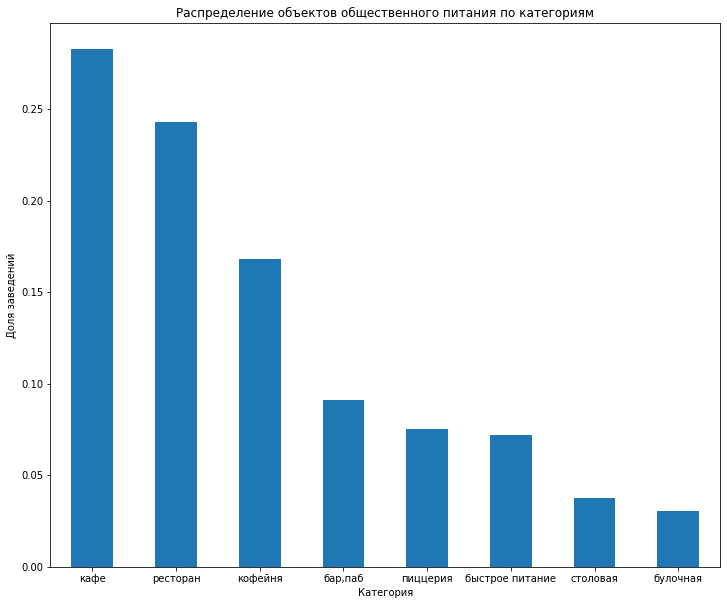

In [27]:
# Визуализируем полученные данные с помощью столбчатой диаграммы:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 10))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts(normalize=True).plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Распределение объектов общественного питания по категориям'
)

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Доля заведений')

# Выводим график
plt.show()


Кафе лидирует по количеству объектов - 2376 (28%), за ним следуют рестораны и кофейни; бары, пабы, пиццерии и другие категории значительно отстают.

---

### Задача 2

Следующим шагом, необходимо оределить какие регионы Москвы наиболее популярны среди владельцев заведений общественного питания. Для этого, исследуем количество заведений по административным регионам Москвы.

In [28]:
# Проверяем распределение данных по значениям в столбце 'district' в относительном и абсолютном значениях
district_relative = df['district'].value_counts(normalize=True)
district_absolute = df['district'].value_counts()

# Объединяем значения в одну таблицу с помощью метода pd.concat()
pd.concat([district_absolute, district_relative], axis=1, keys=['', ''])

,,
Центральный административный округ,2242,0.266841
Северный административный округ,898,0.106879
Южный административный округ,892,0.106165
Северо-Восточный административный округ,890,0.105927
Западный административный округ,850,0.101166
Восточный административный округ,798,0.094977
Юго-Восточный административный округ,714,0.084980
Юго-Западный административный округ,709,0.084385
Северо-Западный административный округ,409,0.048679


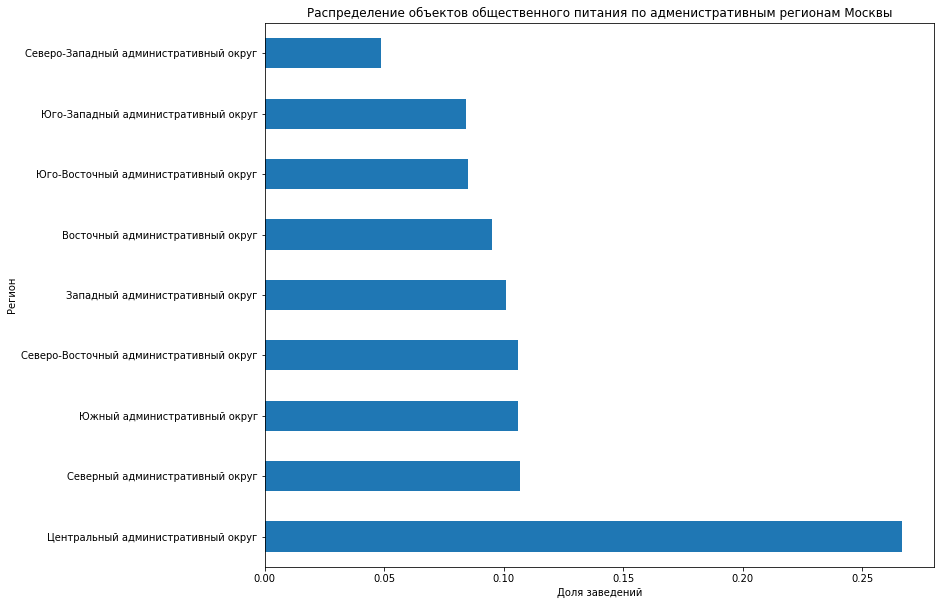

In [29]:
# Визуализируем полученные данные с помощью горизонтальной столбчатой диаграммы:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 10))

# Строим линейчатую диаграмму с помощью pandas через plot(kind='barh')
df['district'].value_counts(normalize=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Распределение объектов общественного питания по адменистративным регионам Москвы'
)

# Настраиваем оформление графика
plt.xlabel('Доля заведений')
plt.ylabel('Регион')

# Выводим график
plt.show()


Наибольшее количество заведений (26%) расположены в Центральном административном округе, доля заведений в других регионах Москвы приблизительно одинаковое. Посмотрим детальнее, какие категории объектов общественного питания преобладают в Центральном административном округе. 

In [30]:
# Отфильтруем данные и выберем заведения, расположенные только в Центральном административном округе
# Результат сохраним в переменную df_tsao:
df_tcao = df[df['district'] == 'Центральный административный округ']

# Проверяем распределение данных по значениям в столбце 'category' для ЦАО в относительном и абсолютном значениях
tcao_relative = df_tcao['category'].value_counts(normalize=True)
tcao_absolute = df_tcao['category'].value_counts()

# Объединяем значения в одну таблицу с помощью метода pd.concat()
pd.concat([tcao_absolute, tcao_relative], axis=1, keys=['', ''])

,,
ресторан,670,0.298840
кафе,464,0.206958
кофейня,428,0.190901
"бар,паб",364,0.162355
пиццерия,113,0.050401
быстрое питание,87,0.038805
столовая,66,0.029438
булочная,50,0.022302


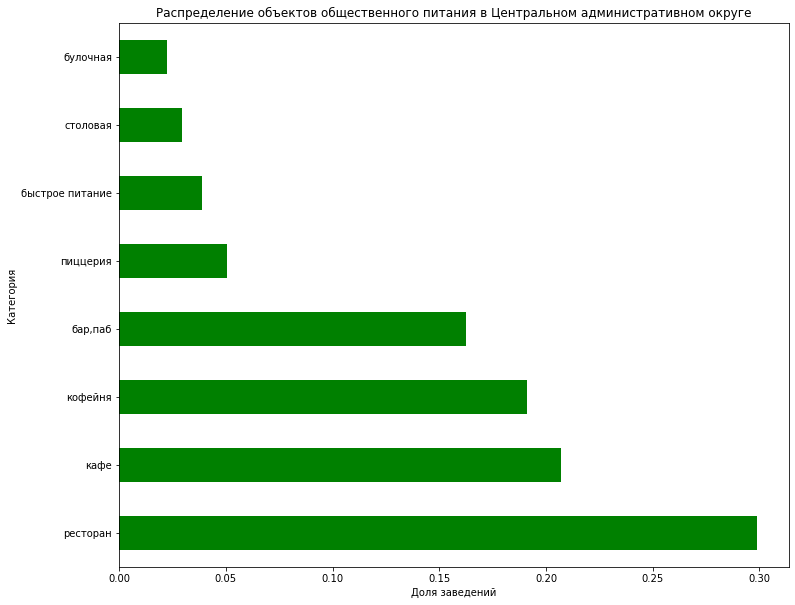

In [31]:
# Визуализируем полученные данные с помощью горизонтальной столбчатой диаграммы:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 10))

# Строим линейчатую диаграмму с помощью pandas через plot(kind='barh')
df_tcao['category'].value_counts(normalize=True).plot(
               kind='barh',
               rot=0,
               legend=False,
               title=f'Распределение объектов общественного питания в Центральном административном округе',
               color='green'
)

# Настраиваем оформление графика
plt.xlabel('Доля заведений')
plt.ylabel('Категория')

# Выводим график
plt.show()

В Центральном административном округе ситуация немного изменилась: по численности заведений лидируют рестораны(30%), однако кафе и кофейни все еще в тройке лидиров. Теперь мы знаем, что в Центре Москвы рестораны открывают чаще, чем другие типы заведений, хотя во всем городе преобладают кафе.

---

### Задача 3

Также, нам необходимо изучить соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Ответим на вопросы: 
* Каких заведений больше — сетевых или несетевых? 
* Какие категории заведений чаще являются сетевыми?

In [32]:
# Проверяем распределение данных по значениям в столбце 'chain'
df['chain'].value_counts(normalize=True)

0    0.618781
1    0.381219
Name: chain, dtype: float64

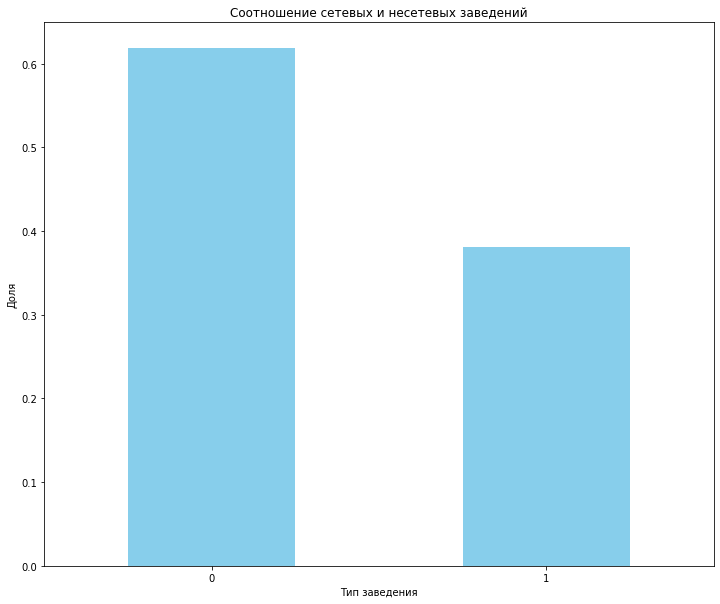

In [33]:
# Визуализируем полученные данные с помощью столбчатой диаграммы:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 10))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['chain'].value_counts(normalize=True).plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Cоотношение сетевых и несетевых заведений',
               color='skyblue'
)

# Настраиваем оформление графика
plt.xlabel('Тип заведения')
plt.ylabel('Доля')

# Выводим график
plt.show()

Судя по графику, доля несетевых заведений превышает долю сетевых в 1,5 раза. Теперь, рассмотрим сетевые и несетевые заведения в разрезе категорий.

In [34]:
# К методу value_counts() Добавим группировку по столбцу 'category':
grouped_chain = df.groupby('category')['chain'].value_counts().unstack(fill_value=0) 

grouped_chain

chain,0,1
category,,
"бар,паб",596,168
булочная,99,157
быстрое питание,371,232
кафе,1597,779
кофейня,693,720
пиццерия,303,330
ресторан,1313,729
столовая,227,88


<Figure size 864x720 with 0 Axes>

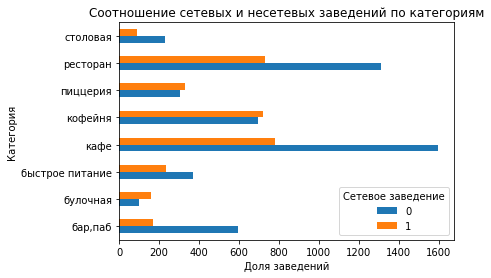

In [35]:
# Визуализируем полученные данные с помощью горизонтальной столбчатой диаграммы:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 10))

# Строим линейчатую диаграмму с помощью pandas через plot(kind='barh')
grouped_chain.plot(
               kind='barh',
               rot=0,
               legend=True,
               title=f'Cоотношение сетевых и несетевых заведений по категориям'
)

# Настраиваем оформление графика
plt.xlabel('Доля заведений')
plt.ylabel('Категория')
plt.legend(title='Сетевое заведение')

# Выводим график
plt.show()

Сетевыми заведениями чаще являются кофейни, пиццерии и булочные, в то время как остальные категории заведений больше несетевые. 

К тому же, доля несетевых кафе превышает сетевые почти в 2 раза.

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Узнаем, встречаются ли в данных аномальные значения или выбросы и с чем они могут быть связаны. Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест.


In [36]:
# Так как мы заменили пропуски на значение-индикатор "-1", отфильтруем данные в столбце 'seats'
df_filtered_seats = df[df['seats'] >= 0].copy()

# Изучаем статистику только для валидных значений
print(df_filtered_seats['seats'].describe())

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64


Среднее количество посадочных мест 108.361436 и медиана 75.000000 сильно различаются, что указывает на ассимметричное распределение данных с выраженными выбросами. К тому же, значение стандартного отклонения довольно высокое — 122.841130, и при среднем 108.361436 это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.

Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха для столбца с количеством посадочных мест.

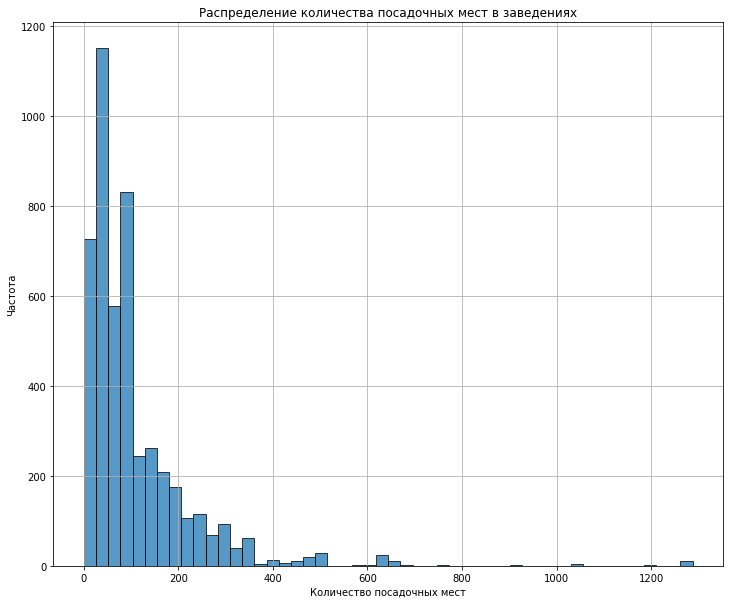

In [37]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 10))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_filtered_seats['seats'].plot(
                kind='hist',
                bins=50,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

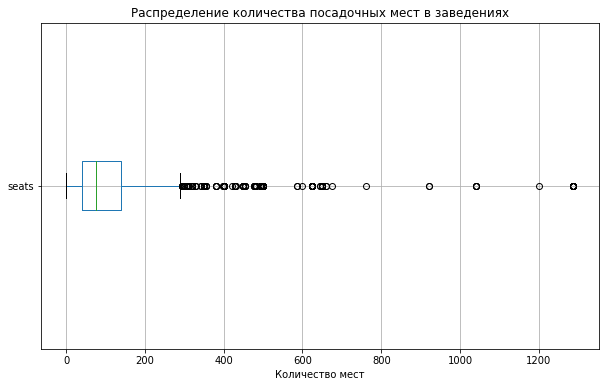

In [38]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим диаграмму размаха значений в столбце seats
df_filtered_seats.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество мест')

# Выводим график
plt.show()

Распределение данных действительно выглядит ассимитричным и характеризуется широким разбросом и «хвостом» в правой части гистограммы. Такие высокие значения можно отнести к выбросам. Однако сами значения могут не быть ошибкой, в случае, если для сетевых заведений было указано общее количество посадочных мест для всех объектов сети. При анализе данных их оставим, так как они не могут помешать нам определить для каждой категории заведений наиболее типичное для него количество посадочных мест.

In [39]:
# Фильтруем валидные seats: те, что больше 0 и меньше 300
df_valid = df[df['seats'] >= 0].copy()

# Группируем данные по категории и вычисляем медиану количества посадочных мест
typical_seats = df_valid.groupby('category')['seats'].median()

# Выводим результат
typical_seats

category
бар,паб            82.0
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           75.5
Name: seats, dtype: float64

Типичное количество посадочных мест варьируются в диапазоне от 50 до 86. Самое высокое значение - 86 посадочных мест характерно для ресторанов, а самое маленькое значение(50) характерно для булочных. Все значения не выглядят аномальными и вполне соответствуют каждой из категорий.

---

### Задача 5

Теперь, исследуем рейтинг заведений и визуализируем распределение средних рейтингов по категориям заведений чтобы узнать, сильно ли различаются усреднённые рейтинги для разных типов общепита.

In [41]:
# Изучаем статистические показатели столбца 'rating'
df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

Можно предположить, что данные рейтинга имеют распределение, близкое к нормальному. Об этом говорит близость среднего и медианного значений. Однако значение стандартного отклонения довольно высокое — 0.470320, и при среднем 4.230017 это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.

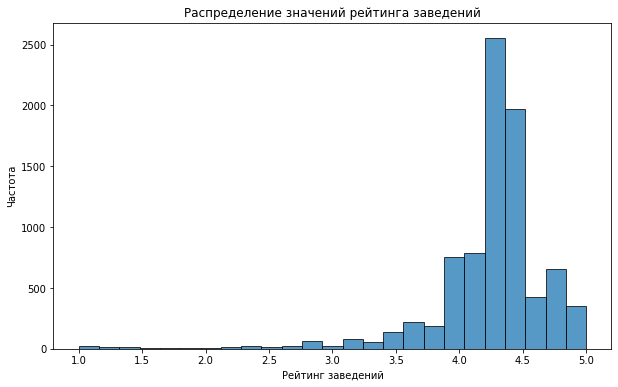

In [42]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['rating'].plot(
                kind='hist',
                bins=25,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение значений рейтинга заведений')
plt.xlabel('Рейтинг заведений')
plt.ylabel('Частота')

# Выводим график
plt.show()

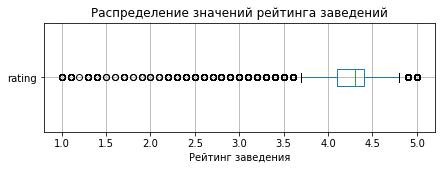

In [43]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='rating', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений рейтинга заведений')
plt.xlabel('Рейтинг заведения')

# Выводим график
plt.show()

Распределение данных выглядит ассимитричным и характеризуется широким разбросом и «хвостами» как в левой, так и в правой части гистограммы. Такие низкие и высокие значения можно отнести к выбросам. Однако сами значения, как минимальные, так и максимальные, не выглядят ошибкой, и такой рейтинг у заведений вполне возможен. Поэтому при анализе данных их оставим.

Теперь, рассмотрим распределения рейтинга в разрезе категорий заведений. 

In [44]:
# Группируем данные по категории и посчитаем средний рейтинг для каждой из них
mean_rating = df.groupby('category')['rating'].mean()

mean_rating

category
бар,паб            4.387696
булочная           4.268359
быстрое питание    4.050249
кафе               4.124285
кофейня            4.277282
пиццерия           4.301264
ресторан           4.290402
столовая           4.211429
Name: rating, dtype: float64

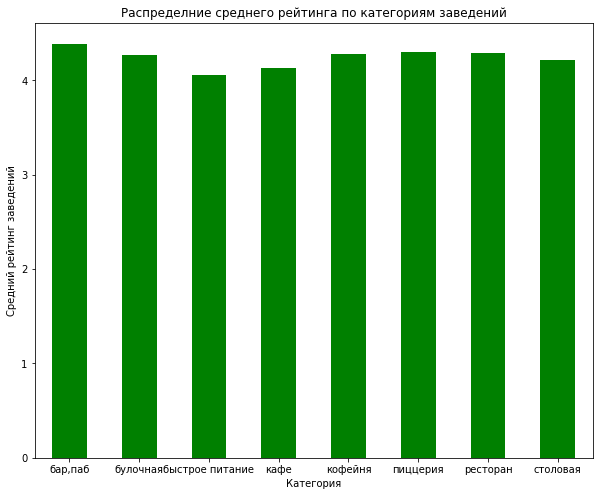

In [45]:
# Визуализируем полученные данные с помощью столбчатой диаграммы:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 8))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
mean_rating.plot(
               kind='bar',
               rot=0,
               legend=False,
               title=f'Распределние среднего рейтинга по категориям заведений',
               color='green'
)

# Настраиваем оформление графика
plt.xlabel('Категория')
plt.ylabel('Средний рейтинг заведений')

# Выводим график
plt.show()

Усредненные рейтинги для каждой категории объектов общественного питания примерно одинаковы. Они находятся в диапазоне от 4.0 до 4.4. Исходя из этого, можно предположить, что рейтинг не зависит от типа заведения.

---

### Задача 6

В этом шаге, мы изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным.

Рассчитаем матрицу корреляции phi_k для данных о заведениях общественного питания в Москве:

In [46]:
# Вычисляем корреляционную матрицу с использованием phi_k
# Создаем копию для корреляции 
df_corr = df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].copy() 

# Заменяем заглушки на pd.NA с помощью метода replace() 
df_corr['seats'] = df_corr['seats'].replace(-1, pd.NA) 
df_corr['price'] = df_corr['price'].replace('Неизвестно', pd.NA) 

# Вычисляем корреляцию 
correlation_matrix = df_corr.phik_matrix() 

# Результат 
corr_rating = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']] 
corr_rating.sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'rating']


/opt/conda/lib/python3.9/site-packages/pandas/core/missing.py:56: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= arr == x


,rating
price,0.220295
district,0.200761
category,0.189716
seats,0.152723
is_24_7,0.150365
chain,0.107833


Перед тем как перейти к дальнейшему анализу, визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn:

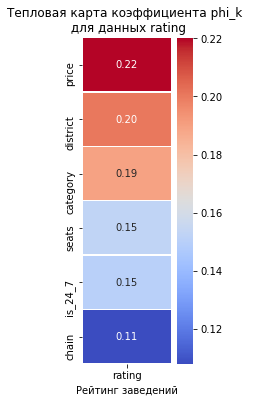

In [47]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            cbar=True
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг заведений')

# Выводим график
plt.show()

Ярко-выраженой корреляции между рейтингом и другими признаками не видно. Наибольшая корреляция рейтинга заведений наблюдается с ценовой категорией (0.22). Для остальных признаков коэффициент корреляции снижается с 0.20 до 0.11. 

Проверим детальнее самую сильную связь. Изучим, существует ли зависимость между рейтингом заведения и ценовой категорией. Для этого построим столбчатую диаграмму с разделением по признаку rating среди разных ценовых категорий:

In [48]:
# Исключим из анализа значение "Неизвестно", которым заменили пропуски ранее
filtered_price = df[df['price'] != 'Неизвестно']

# Рассчитаем значения среднего рейтинга для каждой ценовой категории заведений
mean_rating_price = filtered_price.groupby('price')['rating'].mean()

# Выведем полученный результат
print(f'Средний рейтинг по ценовым категориям заведений:')
print(mean_rating_price)

# Рассчитаем и выведем средний рейтинг по всем заведениям
print(f'\n Средний рейтинг всех заведений:')
print(round(df['rating'].mean(),2))

Средний рейтинг по ценовым категориям заведений:
price
высокие          4.436611
выше среднего    4.386348
низкие           4.173077
средние          4.297874
Name: rating, dtype: float64

 Средний рейтинг всех заведений:
4.23


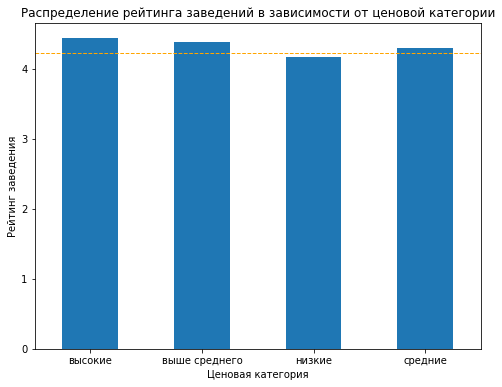

In [49]:
# Построим график столбчатой диаграммы
grouped = filtered_price.groupby('price')['rating'].mean()
grouped.plot(kind='bar',
               title=f'Распределение рейтинга заведений в зависимости от ценовой категории',
               legend=False,
               ylabel='Рейтинг заведения',
               xlabel='Ценовая категория',
               rot=0,
               figsize=(8, 6))


# Рассчитываем среднее значение по рейтингу заведений
mean_rating_share = df['rating'].mean()

# Наносим на график линию со средним значением рейтинга заведений
plt.axhline(mean_rating_share,
            color='orange',
            linestyle='--',
            linewidth=1,
            label=f'Рейтинг заведений {round(mean_rating_share,4)}')

# Выводим график
plt.show() 


Судя по графику, нельзя говорить о какой либо взаимосвязи между рейтингом заведений и ценовой категорией. Средний рейтинг для каждой категории не сильно различается (в диапазоне 4.17 - 4.43) и приблизительно равен среднему рейтингу по всем заведениям(4.23). Однако, чем выше ценовая категория заведения, тем выше средний рейтинг заведений. Соответственно, небольшая корреляция между ценовой категорией заведения и его рейтингом наблюдается, но говорить о точной взаимосвязи мы не можем.

---

### Задача 7

Определим топ-15 популярных сетей по количеству заведений в Москве, для этого сгруппирем данные по названиям заведений. Для них посчитаем значения среднего рейтинга. Нам нужно определить, к какой категории заведений они относятся.

In [51]:
# Отбираем только сетевые заведения
chain_filtered = df[df['chain'] == 1].copy()

# Считаем количество заведений по сети и категории с помощью сводной таблицы (метода pivot_table())
pivot = pd.pivot_table(
    chain_filtered,
    index=['name', 'category'],
    values='rating',
    aggfunc=['count', 'mean']
).reset_index()

# Переименуем колонки
pivot.columns = ['name', 'category', 'count_object', 'mean_rating']

# Для каждой сети оставляем категорию с наибольшим количеством заведений
pivot_main_category = (
    pivot
    .sort_values('count_object', ascending=False)
    .drop_duplicates(subset='name')
)

# Сортируем сети по количеству заведений и берём топ-15
top_15_chains = (
    pivot_main_category
    .sort_values('count_object', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

# Выводим результат
top_15_chains


,name,category,count_object,mean_rating
0,шоколадница,кофейня,119,4.178151
1,домино'с пицца,пиццерия,76,4.169737
2,додо пицца,пиццерия,74,4.286486
3,one price coffee,кофейня,71,4.064789
4,яндекс лавка,ресторан,69,3.872464
5,cofix,кофейня,65,4.075385
6,prime,ресторан,49,4.114286
7,кофепорт,кофейня,42,4.147619
8,кулинарная лавка братьев караваевых,кафе,39,4.394872
9,теремок,ресторан,36,4.105556


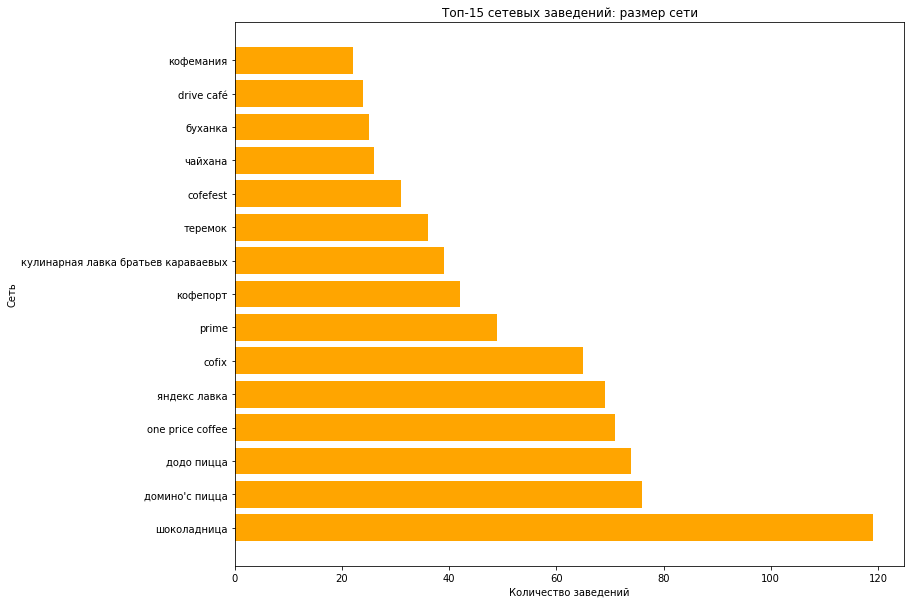

In [55]:
# Визуализируем размеры сетей:
# Задаем размер линейчатой диаграммы
plt.figure(figsize=(12, 10))

# Строим линейчатую диаграмму через plt.barh()
plt.barh(
    y=top_15_chains['name'],
    width=top_15_chains['count_object'],
    color='orange'
)

# Настраиваем оформление графика
plt.title('Топ-15 сетевых заведений: размер сети')
plt.xlabel('Количество заведений')
plt.ylabel('Сеть')

# Выводим результат
plt.show()


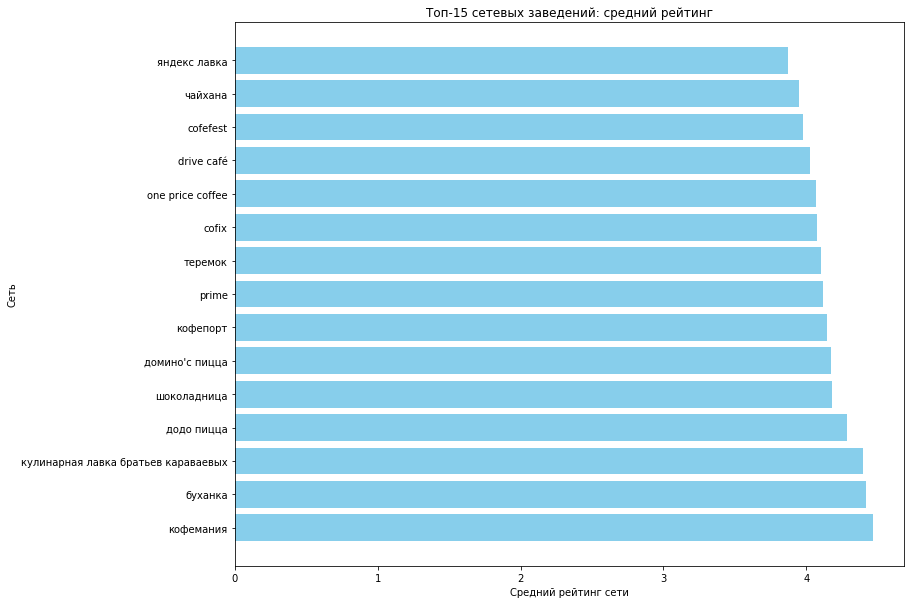

In [56]:
# Визуализация для средних рейтингов сетей:
# Отсортируем значения средних рейтингов в порядке убывания
top_15_sorted = top_15_chains.sort_values(by='mean_rating',ascending=False)

# Задаем размер линейчатой диаграммы
plt.figure(figsize=(12, 10))

# Строим линейчатую диаграмму через plt.barh()
plt.barh(
    y=top_15_sorted['name'],
    width=top_15_sorted['mean_rating'],
    color='skyblue'
)

# Настраиваем оформление графика
plt.title('Топ-15 сетевых заведений: средний рейтинг')
plt.xlabel('Средний рейтинг сети')
plt.ylabel('Сеть')

# Выводим результат
plt.show()

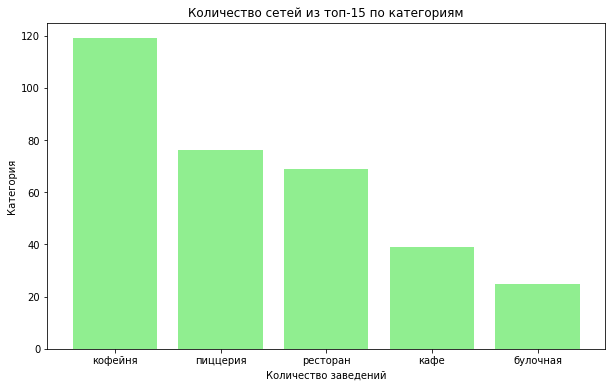

In [57]:
# Создаем диаграмму
plt.figure(figsize=(10, 6))
plt.bar(top_15_chains['category'], 
        top_15_chains['count_object'], 
        color='lightgreen')

# Добавляем подписи к оси X и Y, заголовок диаграммы
plt.xlabel('Количество заведений')
plt.ylabel('Категория')

# Заголовок диаграммы
plt.title('Количество сетей из топ-15 по категориям')

# Выводим график
plt.show() 

В топ-15 сетевых заведений по количеству объектов в сети вошли заведения из категорий "кофейня", "пиццерия", "ресторан", "кафе", и "булочная". Чаще всех встречаются кофейни среди топ-15 заведений общественного питания. Средний рейтинг заведений варьируется в диапазоне от 3.87 до 4.46. Самой большой сетью из топ-15 является "Шоколадница", которая включает в себя 119 заведений из категории "кофейня" и имеет средний рейтинг 4.18. Самой маленькой сетью из топа является "Кофемания", которая состоит всего из 22 кофеен, однако имеет самый высокий рейтинг (4.46).

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [58]:
# Отфильтруем данные и выберем заведения, средние чеки которых больше 0, так как ранее мы заменяли пропуски в столбце значением "-1"
# Результат сохраним в переменную df_filtered_bill:
df_filtered_bill = df[df['middle_avg_bill'] >0]

In [59]:
# Выведем статистические показатели данных по среднему чеку заведений с помощью метода .describe()
df_filtered_bill['middle_avg_bill'].describe()

count     3148.000000
mean       958.358005
std       1009.748800
min         30.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

Среднее значение среднего чека заведений 958.358005 и медиана 750.000000 сильно различаются, что указывает на ассимметричное распределение данных с выраженными выбросами. К тому же, значение стандартного отклонения довольно высокое — 1009.748800, и, при среднем 958.358005, указывает на то, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.

Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха для столбца со средним чеком заведний.

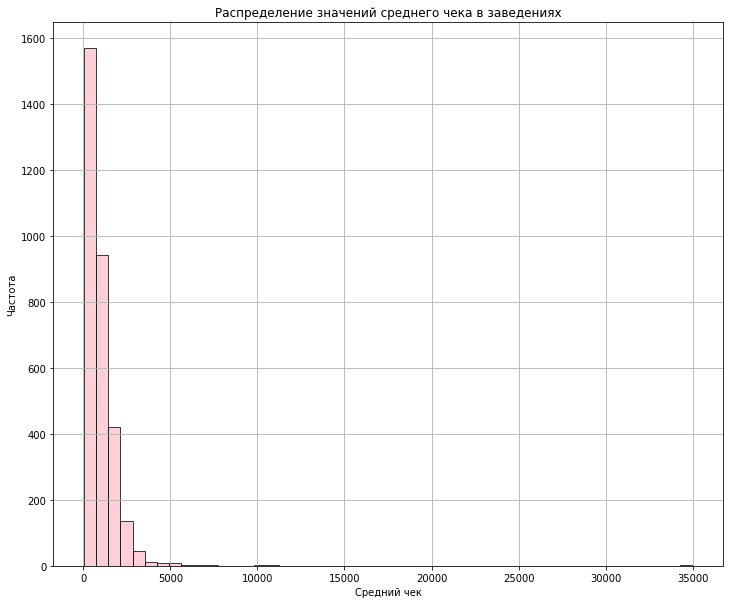

In [60]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 10))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df_filtered_bill['middle_avg_bill'].plot(
                kind='hist',
                bins=50,
                alpha=0.75,
                edgecolor='black',
                color='pink' 
)

# Настраиваем оформление графика
plt.title('Распределение значений среднего чека в заведениях')
plt.xlabel('Средний чек')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

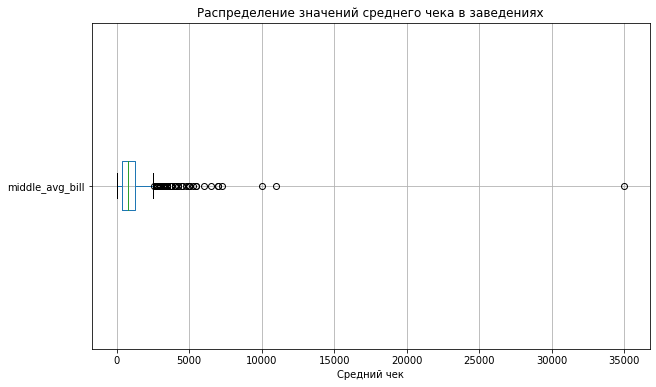

In [61]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим диаграмму размаха значений в столбце seats
df_filtered_bill.boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений среднего чека в заведениях')
plt.xlabel('Средний чек')

# Выводим график
plt.show()

Распределение данных действительно выглядит ассимитричным и характеризуется широким разбросом и «хвостом» в правой части гистограммы. Такие высокие значения можно отнести к выбросам. Однако сами значения могут не быть ошибкой, например если заведения находятся в центральной части Москвы и имеют высокую ценовую категорию. Поэтому, при анализе данных их оставим.

In [62]:
# Сгруппируем данные по району и посчитаем средний чек для каждого района
mean_avg_bill = df_filtered_bill.groupby('district')['middle_avg_bill'].mean().reset_index()

# Выведем результат
mean_avg_bill

,district,middle_avg_bill
0,Восточный административный округ,820.626923
1,Западный административный округ,1053.225490
2,Северный административный округ,927.959627
3,Северо-Восточный административный округ,716.611296
4,Северо-Западный административный округ,822.222930
5,Центральный административный округ,1192.182247
6,Юго-Восточный административный округ,654.097938
7,Юго-Западный административный округ,792.561702
8,Южный административный округ,834.398089


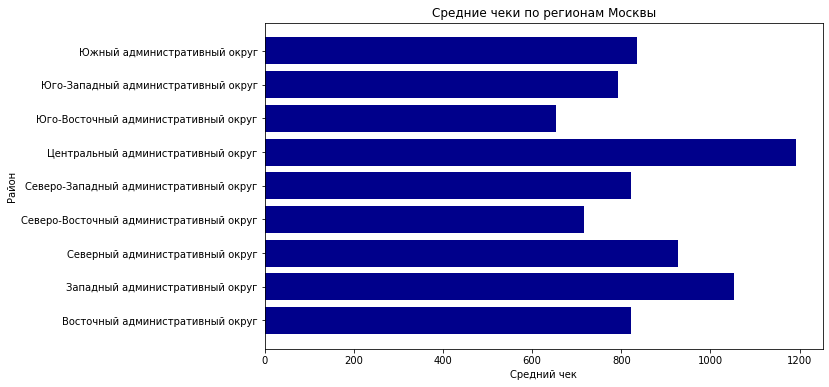

In [63]:
# Создаем линейчатую диаграмму
plt.figure(figsize=(10, 6))
plt.barh(mean_avg_bill['district'], mean_avg_bill['middle_avg_bill'], color='darkblue')

# Добавляем подписи к оси X и Y
plt.xlabel('Средний чек')
plt.ylabel('Район')

# Заголовок диаграммы
plt.title('Средние чеки по регионам Москвы')

# Показываем диаграмму
plt.show() 

Средний чек в Центральном административном округе значительно выше, чем в других районах города. Это говорит нам о том, что размер среднего чека может зависеть от того, где расположено заведение. Заведения с более высокими средними чеками располагаются в Центральном, Западном и Северном административных округах. Наименьшие средние чеки сосредоточены в Северо-Восточном и Юго-восточном административных округах. Чем ближе заведение к центру, тем выше может быть его средний чек.

---

### Промежуточный вывод

**В процессе исследовательского анализа данных были изучены данные о заведениях общественного питания, расположенных в Москве. Были решены следующие задачи:**
1. Изучили категории заведений и количество объектов общественного питания по каждой категории. 
2. Изучили административные районы Москвы с распределением количества заведений по каждому району, а также отдельно изучено распределение заведений каждой категории в Центральном административном округе Москвы. 
3. Изучили соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. 
4. Исследовали количество посадочных мест в заведениях на предмет аномальных значений и выбросов? Для каждой категории заведений приведено наиболее типичное для нее количество посадочных мест. 
5. Исследовали рейтинг заведений и распределение средних рейтингов по категориям заведений.
6. Изучили корреляцию рейтингов заведений с другими данными: его категория, положение, статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным.Самая сильная связь было проверена отдельно.
7. Выделили топ-15 популярных сетей в Москве и посчитали для них значения среднего рейтинга. Выделены категории, к которым относятся эти заведения.
8. Изучили вариацию среднего чека заведения в зависимости от района Москвы. Проанализировали цены в центральном административном округе и других. 
9. Все результаты анализа сопроводили подходящими визуализациями.

**Подводя промежуточные итоги исследовательского анализа данных, сделаны следующие выводы:**
1. Кафе, рестораны и кофейни лидируют по количеству объектов общественного питания.
2. Наибольшее количество заведений расположено в Центральном административном округе. В Центральном административном округе по численности заведений лидируют рестораны, кафе и кофейни.
3. Доля несетевых заведений превышает долю сетевых в 1,5 раза. Сетевыми заведениями чаще являются кофейни, пиццерии и булочные, в то время как остальные категории заведений больше несетевые.
4. Типичное количество посадочных мест большинства типов заведений варьируются в диапазоне от 50 до 86. Самое высокое значение характерно для ресторанов, а самое маленькое - для булочных.
5. Усредненные рейтинги для каждой категории объектов общественного питания находятся в диапазоне от 4.0 до 4.4. Можно предположить, что рейтинг не зависит от типа заведения.
6. Наблюдается небольшая корреляция между ценовой категорией заведения и его рейтингом, но говорить о точной взаимосвязи мы не можем.
7. В топ-15 сетевых заведений по количеству объектов в сети вошли заведения из категорий "кофейня", "пиццерия", "ресторан", "кафе", и "булочная". Средний рейтинг этих заведений варьируется в диапазоне от 3.87 до 4.46. 
8. Средний чек в Центральном административном округе значительно выше, чем в других районах города.  Чем ближе заведение к центру, тем выше может быть его средний чек.

**Практические рекомендации для бизнеса общепита**
На основе проведенного анализа можно предложить следующие практические рекомендации:

1. Выбор категории и локации
    Приоритет для запуска - кафе и кофейни в Центральном административном округе: максимальный спрос и высокая платежеспособность клиентов.
    Рестораны также перспективны в центре.


2. Ценовая политика
    Центр: средний чек на 30-50% выше.
    Периферия: фокусируйтесь на соотношении цена/качество, избегайте высоких чеков.

3. Управление ожиданиями клиентов (рейтинг)
    Целевой рейтинг 4.2-4.4 реалистичен для всех категорий — фокусируйтесь на стабильности.
    Отсутствие корреляции рейтинг-категория означает, что успех зависит от сервиса, а не концепции.
    Мониторинг конкурентов в топ-15 сетей (3.87-4.39) — ориентир для входа на рынок.

4. Стратегические приоритеты
    1. Запуск кофейни/кафе в ЦАО (высокий спрос + высокий чек)
    2. Масштабирование пиццерий/булочных в сеть (низкий риск)
    3. Стандартизация 40-60 мест (оптимальная загрузка)
    4. Ценообразование по расположению (центр и периферия)
    
 
**Наиболее перспективное направление:** открытие сетевой кофейни в Центральном административном округе с типичной вместимостью 50 мест и средним чеком выше среднего по городу.

## 4. Итоговый вывод и рекомендации
В процессе выполнения проекта была проделана следующая работа:

**1. Предобработка данных:**

    1) Приведение столбцов к правильным типам данных:    
       * Оптимизировали тип данных в столбце chain, значения привели к типу int8;
       * В столбце seats данные привели к типу int64.
        
    2) Обработка пропусков:    
       * Для столбца 'hours' пропущенные значения заменили значением "Время работы неизвестно", а для столбцов 'avg_bill' и 'price' значением "Неизвестно".
       * Для столбцов 'seats', 'middle_avg_bill' и 'middle_coffee_cup' использовали значение-индикатор "-1".
        
    3) Удаление дубликатов:    
       * Проверили наличие явных и неявных дубликатов в категориальных столбцах;
       * После приведения значений в столбцах name и address к нижнему регистру, были удалены 4 дублирующихся значения.


**Результаты предобработки:**

Было строк в исходном датасете: `8406`;

Осталось строк в датасете после обработки: `8402`;

Удалено строк в датасете после обработки: `4`;

Процент потерь: `0.05%`.
        

**2. Исследовательский анализ данных**

1. Изучение категорий заведений и количества объектов общественного питания по каждой категории.
2. Изучение административных районов Москвы с распределением количества заведений по каждому району, а также отдельно изучены распределение заведений каждой категории в Центральном административном округе Москвы.
3. Изучение соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.
4. Исследование количества посадочных мест в заведениях на предмет аномальных значений и выбросов. Для каждой категории заведений приведено наиболее типичное для нее количество посадочных мест.
5. Исследование рейтингов заведений и распределение средних рейтингов по категориям заведений.
6. Изучение корреляции рейтингов заведений с другими данными: его категория, положение, статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Самая сильная связь была проверена отдельно.
7. Выделение топ-15 популярных сетей в Москве и подсчет для них значений среднего рейтинга. Выделение категорий, к которым относятся эти заведения.
8. Изучение вариации среднего чека заведения в зависимости от района Москвы. Анализ цен в центральном административном округе и других.
9. Все результаты анализа сопровождались подходящими визуализациями.

**Выводы:**

1. Кафе, рестораны и кофейни лидируют по количеству объектов общественного питания.
2. Наибольшее количество заведений расположено в Центральном административном округе. В Центральном административном округе по численности заведений лидируют рестораны, кафе и кофейни.
3. Доля несетевых заведений превышает долю сетевых в 1,5 раза. Сетевыми заведениями чаще являются кофейни, пиццерии и булочные, в то время как остальные категории заведений больше несетевые.
4. Типичное количество посадочных мест большинства типов заведений варьируются в диапазоне от 50 до 86. Самое высокое значение характерно для ресторанов, а самое маленькое - для булочных.
5. Усредненные рейтинги для каждой категории объектов общественного питания находятся в диапазоне от 4.0 до 4.4. Можно предположить, что рейтинг не зависит от типа заведения.
6. Наблюдается небольшая корреляция между ценовой категорией заведения и его рейтингом, но говорить о точной взаимосвязи мы не можем.
7. В топ-15 сетевых заведений по количеству объектов в сети вошли заведения из категорий "кофейня", "пиццерия", "ресторан", "кафе", и "булочная". Средний рейтинг этих заведений варьируется в диапазоне от 3.87 до 4.46. 
8. Средний чек в Центральном административном округе значительно выше, чем в других районах города.  Чем ближе заведение к центру, тем выше может быть его средний чек.

**Рекомендации**
1. Выбор категории и локации

* Приоритет для запуска - кафе и кофейни в Центральном административном округе: максимальный спрос и высокая платежеспособность клиентов.

* Рестораны также перспективны в центре.


2. Ценовая политика

* Центр: средний чек на 30-50% выше.
    
* Периферия: фокусируйтесь на соотношении цена/качество, избегайте высоких чеков.

3. Управление ожиданиями клиентов (рейтинг)

* Целевой рейтинг 4.2-4.4 реалистичен для всех категорий — фокусируйтесь на стабильности.

* Отсутствие корреляции рейтинг-категория означает, что успех зависит от сервиса, а не концепции.

* Мониторинг конкурентов в топ-15 сетей (3.87-4.39) — ориентир для входа на рынок.

4. Стратегические приоритеты

    1. Запуск кофейни/кафе в ЦАО (высокий спрос + высокий чек)
    2. Масштабирование пиццерий/булочных в сеть (низкий риск)
    3. Стандартизация 40-60 мест (оптимальная загрузка)
    4. Ценообразование по расположению (центр и периферия)
    
 
**Наиболее перспективное направление:** открытие сетевой кофейни в Центральном административном округе с типичной вместимостью 50 мест и средним чеком выше среднего по городу.